In [1]:
%matplotlib notebook
import sys
sys.path.append('/opt/proteus/linux/bin')
import matplotlib.pyplot as plt
import numpy as np
import math
from proteus.iproteus import *
import proteus.default_p as physics 
import proteus.default_n as numerics 
from proteus.TransportCoefficients import PoissonEquationCoefficients
import matplotlib.tri as tri
import os
os.environ['PATH']+=':/opt/proteus/linux/bin'
#print(os.environ)

#----------------------------------------------------------------
# define physics
#----------------------------------------------------------------
def r(x):
    return 0.

def a(x):
    return np.array([[1.0,0.0],
                     [0.0,1.0]])
physics.coefficients = PoissonEquationCoefficients([a],[r]) 
physics.name="PoissonDots"

#----------------------------------------------------------------
# define domain
#----------------------------------------------------------------
grav = 9.81
h = 0.4 # water depth
L = 30. # tank length
physics.nd = 2 # domain dimension

# used for quadrilateral mesh # PlanarStraightLineGraphDomain does not work for quadrilateral mesh
physics.domain = Domain.RectangularDomain(L=[L,h])
physics.domain.writePoly('quadmesh')

#----------------------------------------------------------------
# define initial BCs for trivial BVP
#----------------------------------------------------------------
def getDBC_0(x,flag):
    if flag in [physics.domain.boundaryTags['top']]:
        return lambda x,t: 0.
    
def getIBC_0(x,flag):
    if flag in [physics.domain.boundaryTags['right']]:
        return lambda x,t: 0.
    elif flag in [physics.domain.boundaryTags['left']]:
        return lambda x,t: 0.
    elif flag in [physics.domain.boundaryTags['bottom']]:
        return lambda x,t: 0.
    
physics.dirichletConditions = {0:getDBC_0}
physics.advectiveFluxBoundaryConditions = {0:getIBC_0}

#----------------------------------------------------------------
# define numerics
#----------------------------------------------------------------
numerics = default_n
numerics.femSpaces = {0:FemTools.Q1} # Q1 = linear quadralateral element
numerics.elementQuadrature = Quadrature.CubeGaussQuadrature(physics.nd,3)
numerics.elementBoundaryQuadrature = Quadrature.CubeGaussQuadrature(physics.nd-1,3)

#----------------------------------------------------------------
# mesh for rectangle domain
#----------------------------------------------------------------
he = 0.2
nex = int(math.ceil(L/he)) # element number along x direction
ney = int(math.ceil(h/he)) # element number along y direction
nx = nex + 1
ny = ney + 1
numerics.genMesh = True
numerics.nn = None
numerics.nnx  = nx
numerics.nny = ny
numerics.quad = True
numerics.numericalFluxType = NumericalFlux.Diffusion_SIPG_exterior

so = default_so
so.name = physics.name
so.sList=[default_s]
so.tnList = [0,1]

#----------------------------------------------------------------
# give bathymetry and domain mapping
#----------------------------------------------------------------
def bathymetry():
    xb= np.array([[ 0.,  0.],
                  [ 6.,  0.],
                  [12.,  0.3],
                  [14.,  0.3],
                  [17.,  0.],
                  [30.,  0.]])
    nb = len(xb)
    assert xb[-1,0] == L and np.all(xb[:,1] < h),'bathymetry error'
    return nb,xb
    
def domain_mapping(h,nb,xb,n,x): # re-scale the element size by mapping the even-distributed node on the actual water depth
    xx = np.zeros((nnode,2))
    for i in range(nnode):
        for j in range(nb-1):
            l1 = xb[j,0]
            l2 = xb[j+1,0]
            if l1 <= x[i,0] <= l2:
                h1 = h-xb[j,1]
                h2 = h-xb[j+1,1]
                hi = h1+(h2-h1)*(x[i,0]-l1)/(l2-l1)
                yb = h-hi
                xx[i,0] = x[i,0]
                xx[i,1] = yb+x[i,1]*hi/h
    x = xx
    return x

def find_FSnode(n,x):
    epi = 1.e-7
    # define global index of the free-surface nodes for time marching
    ifs = []
    for i in range(n):
        if abs(x[i][1]-h) <epi:   # free surface
            ifs.append(i)  
    nfs = len(ifs)
    return nfs,ifs

# solve trivial BVP
ns = NumericalSolution.NS_base(so,[physics],[numerics],so.sList,opts)
failed = ns.calculateSolution('bvpsolver')
assert(not failed)

# add this line to avoid "ipython is not defined"
%matplotlib inline 
model = ns.modelList[0].levelModelList[-1]

# get mesh of rectangular domain with Q1 linear quadrilateral
x = model.u[0].femSpace.elementMaps.mesh.nodeArray[:,0:2] # model.mesh.nodeArray[:,0:2] # note that in 2D case, the third column of nodeArray is zero
nnode = model.u[0].femSpace.dofMap.nDOF
ln = model.u[0].femSpace.dofMap.l2g # clockwise, interesting...
ne = len(ln)
phi = model.u[0].dof

# define free-surface node index
[nfs,ifs] = find_FSnode(nnode,x)

# apply bathymetry and mapping
[nb,xb] = bathymetry()
x = domain_mapping(h,nb,xb,nnode,x)


nElementBoundaries_global = 752


In [1]:
from proteus import WaveTools as wt

# gravitational acceleration
g = np.array([0., -9.81, 0.])

# wave options
# For h=0.4, T=2(omega=pi), and H=0.04
# The displacement of the piston-type wavemaker is expected to be 0.029532*sin(pi*t)
# Therefore, the velocity of the paddle is 0.029532*pi*cos(pi*t) = 0.093*cos(pi*t)
wave_period = 2.
wave_height = 0.02
wave_direction = np.array([1., 0., 0.])
wave_type = 'Linear' #'Fenton'  #
fast = 'True'
wave = wt.MonochromaticWaves(period=wave_period,
                             waveHeight=wave_height,
                             mwl=h,
                             depth=h,
                             g=g,
                             waveDir=wave_direction,
                             waveType=wave_type,
                             fast=fast)
wavelength = wave.wavelength

t_temp = 0.
fs_temp = []
u_temp = np.zeros((nfs,3))
xele = []
wavele = []
y_temp = np.linspace(0,h,10)

# for i in range(nfs): #range(len(x_temp)):
#     xele.append(x[ifs[i]][0])
#     u_temp[i][:] = wave.u([x[ifs[i]][0],0.,0.],t_temp)
#     wavele.append(wave.eta([x[ifs[i]][0],0.,0.],t_temp))
    
    
for y in y_temp:
    #xele.append(x[ifs[i]][0])
    print(y,wave.u([0.,y,0.],t_temp))
    u_temp[i][:] = wave.u([0.,y,0.],t_temp)
    
#print(type(wave.u([x[ifs[1]][0],0.,0.],t_temp)))
# print('celerity=',wavelength/wave_period)
# print('paddle velocity=',0.029532*math.pi)
#print(u_temp[0,:])
#print(wave.u([x[2][1],x[2][1],0.],t_temp))
plt.plot(x_temp,fs_temp,xele,wavele,'ok')
#plt.plot(xele,wavele,xele,u_temp[:,0])

NameError: name 'np' is not defined

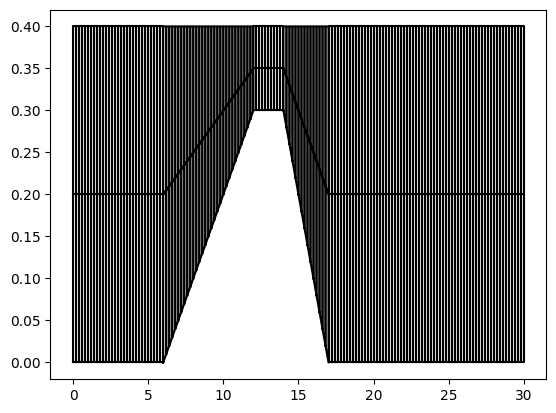

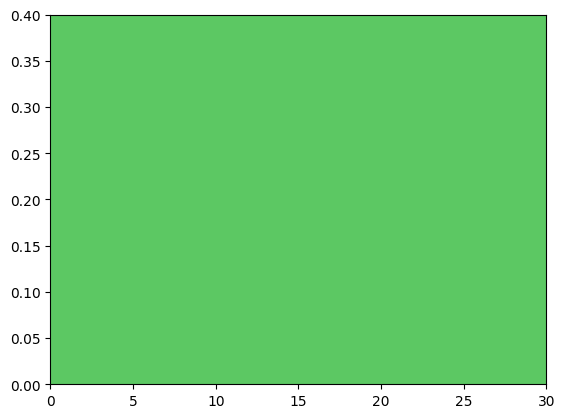

In [21]:
#----------------------------------------------------------------
# check the mesh and first-step solution (should be all zero for a stagnant flow field)
#----------------------------------------------------------------
def plotMesh(elements,nodes):
    from matplotlib import pyplot as plt
    for eN, e in enumerate(elements):
        element_nodes = nodes[e[0]], nodes[e[1]], nodes[e[2]], nodes[e[3]]
        X = [n[0] for n in element_nodes]; Y = [n[1] for n in element_nodes]
        #cx = sum(X)/4.; cy = sum(Y)/4.
        X.append(element_nodes[0][0]); Y.append(element_nodes[0][1])
        plt.plot(X,Y,'-k'); #plt.text(cx, cy, "$T_{{{0:d}}}$".format(eN))
    plt.show()
    return

#plt.figure(1)
#plotMesh(ln,x)
#plt.figure(2)
#plt.tricontourf(x[:,0], x[:,1], phi, 50)
#plt.show()

In [22]:
#----------------------------------------------------------------
# Galerkin method for velocity
#----------------------------------------------------------------
from scipy.sparse import linalg
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import spsolve
from scipy import special

def guass_qua(gq_order):
    if gq_order == 1:
        ng = 1
    elif gq_order == 2:
        ng = 2
    elif gq_order == 3:
        ng = 3
    elif gq_order == 4:
        ng = 4
    
    # distribute ng-by-ng node on the local element
    [x,w] = special.p_roots(ng)
    ngp = ng*ng
    xg = np.zeros((ngp,2))
    wg = []
    c = 0
    for i in range(ng):
        for j in range(ng):
            xg[c][0] = x[j]
            xg[c][1] = x[i]
            wg.append(w[i]*w[j])
            c += 1
    return ngp,xg,wg

def Shapefunctions(xi,eta):
    sha = np.zeros(4)
    sha[0] = 0.25*(1-xi)*(1-eta)
    sha[1] = 0.25*(1+xi)*(1-eta)
    sha[2] = 0.25*(1+xi)*(1+eta)
    sha[3] = 0.25*(1-xi)*(1+eta)
    return sha

def dNdrs(xi,eta):
    # ND = NaturalDerivatives = dSh/dxi and dSh/dita
    ND = np.zeros((2,4))
    ND[0,0] = -0.25*(1-eta) 
    ND[1,0] = -0.25*(1-xi)
    ND[0,1] = 0.25*(1-eta)
    ND[1,1] = -0.25*(1+xi)
    ND[0,2] = 0.25*(1+eta) 
    ND[1,2] = 0.25*(1+xi)
    ND[0,3] = -0.25*(1+eta) 
    ND[1,3] = 0.25*(1-xi)
    return ND

def jacobian(ND,x):
    jcb_tr = np.matmul(ND,x) # this is transpose(J)
    invJ = np.linalg.inv(jcb_tr) # note that invJ = inverse matrix of transpose(J)
    detJ = np.linalg.det(jcb_tr) # note that det(J) = det(transpose(J))
    return invJ,detJ

def local_cd(x,ngp,xg,wg):
    c = np.zeros((4,4))
    d1 = np.zeros((4,4))
    d2 = np.zeros((4,4))    
    for i in range(ngp):
        sha = Shapefunctions(xg[i,0],xg[i,1])
        ND = dNdrs(xg[i,0],xg[i,1])
        [invJ,detJ] = jacobian(ND,x) #ND[][]
        temp = np.matmul(invJ,ND)
        for j in range(4):
            for k in range(4):
                c[j][k] += sha[j]*sha[k]*wg[i]*detJ
                d1[j][k] += sha[j]*temp[0,k]*wg[i]*detJ
                d2[j][k] += sha[j]*temp[1,k]*wg[i]*detJ
    return c,d1,d2

def v_Galerkin(n,ne,ln,ngp,xg,wg,x,phi):
    unod = np.zeros((n,2))
    C = np.zeros((n,n))
    D1 = np.zeros((n,n))
    D2 = np.zeros((n,n))
    for i in range(ne):
        # get local matrices of an element
        [loc_c,loc_d1,loc_d2] = local_cd(x[ln[i,:],:],ngp,xg,wg)

        # assemble local matrices
        for j in range(4):
            for k in range(4):
                C[ln[i][j]][ln[i][k]] += loc_c[j][k]
                D1[ln[i][j]][ln[i][k]] += loc_d1[j][k]
                D2[ln[i][j]][ln[i][k]] += loc_d2[j][k]
                
    # solve u
    b = np.matmul(D1,phi)
    #unod[:,0] = np.linalg.solve(C,b)
    A = csc_matrix(C)
    unod[:,0] = spsolve(A,b)
    
    # solve v
    b = np.matmul(D2,phi)
    #unod[:,1] = np.linalg.solve(C,b)
    A = csc_matrix(C)
    unod[:,1] = spsolve(A,b)    
    
    return unod

# n-by-n gaussian quadrature nodes on a element
gq_order = 2 #  n = 1, 2, 3, 4

# Guassian quadrature
[ngp,xg,wg] = guass_qua(gq_order)    

# solve for the trivial velocity
unod = v_Galerkin(nnode,ne,ln,ngp,xg,wg,x,phi)

In [4]:
#----------------------------------------------------------------
# BVP solver, ALE velocity, and RK4 method
#----------------------------------------------------------------
def getDBC(x,flag):
    if flag in [physics.domain.boundaryTags['top']]:
        return lambda x,t: 0. # should be phi on free surface +++++++++++++++++++++++++

def getIBC(x,flag):
    if flag in [physics.domain.boundaryTags['right']]:
        return lambda x,t: 0. # should be an absorption zone in downstream ++++++++++++++++++++++++++
    elif flag in [physics.domain.boundaryTags['left']]:
        return lambda x,t: 0. # should be pphi on the wavemaker +++++++++++++++++++++++
    elif flag in [physics.domain.boundaryTags['bottom']]:
        return lambda x,t: 0. # zero flux on the bottom
    
def bvp_solver(phi,wmv,x):
    
    # pass current coordinate to Proteus
    # model.u[0].femSpace.elementMaps.mesh.nodeArray[:,0:2] = x ??????
    
    # apply BC
    physics.dirichletConditions = {0:getDBC}
    physics.advectiveFluxBoundaryConditions = {0:getIBC}
    
    # solve bvp
    ns = NumericalSolution.NS_base(so,[physics],[numerics],so.sList,opts)
    failed = ns.calculateSolution('bvpsolver')
    assert(not failed)
    
    # retrieve solution (potential) 
    model = ns.modelList[0].levelModelList[-1]
    phi = model.u[0].dof
    
    return phi

def normal_vector(nfs,ifs,n,x):
    le = np.zeros(nfs-1)
    ne = np.zeros((nfs-1,2))
    normy = np.zeros((nfs,2))
    
    # normal vector of FS side of element
    for i in range(nfs-1): 
        dx = x[ifs[i+1]][0]-x[ifs[i]][0]
        dy = x[ifs[i+1]][1]-x[ifs[i]][1]
        le[i] = np.sqrt(dx**2+dy**2)
        ne[i][0] = -dy/le[i]
        ne[i][1] = dx/le[i]
    
    # nodal normal vector
    normy[0][0] = ne[0][0]
    normy[0][1] = ne[0][1]
    normy[-1][0] = ne[-1][0]
    normy[-1][1] = ne[-1][1]
    for i in range(1,nfs-1): 
        normy[i][0] = (le[i-1]*ne[i-1][0]+le[i]*ne[i][0])/(le[i-1]+le[i])
        normy[i][1] = (le[i-1]*ne[i-1][1]+le[i]*ne[i][1])/(le[i-1]+le[i])         
    return normy

def v_mesh(nfs,ifs,normy,unod,vt):
    vm = np.zeros((nfs,2))
    cv = np.zeros((nfs,2))
    for i in range(nfs):
        vm[i][0] = 0. # the mesh velocity has no horizontal velocity
        vm[i][1] = unod[ifs[i]][1]+(unod[ifs[i]][0]-vm[i][0])*normy[i][0]/normy[i][1]
        cv[i][0] = unod[ifs[i]][0]-vm[i][0]
        cv[i][1] = unod[ifs[i]][1]-vm[i][1]
    return vm,cv

def dpdt_mesh(nfs,ifs,dpdt,cv,unod):
    dpdtm = np.zeros(nfs)
    for i in range(nfs):
        dpdtm[i] = dpdt[ifs[i]]-cv[i][0]*unod[ifs[i]][0]-cv[i][1]*unod[ifs[i]][1]
    return dpdtm

def FSBC_phit(grav,h,ifs,n,x,unod,phi):
    dpdt = np.zeros(n)
    phit = np.zeros(n)
    for i in ifs:
        dpdt[i] = 0.5*(unod[i][0]**2+unod[i][1]**2)-grav*(x[i][1]-h) #-x[i][0]*acc
        phit[i] = dpdt[i]-(unod[i][0]**2+unod[i][1]**2)
    
    # add this section if there is an absorption zone, but it's better done by Proteus' module
#     for i in ifs:
#         if x[i][0] >= damp_zone:
#             dpdt[i] = 0.5*(unod[i][0]**2+unod[i][1]**2)-grav*(x[i][1]-h)-mu*(x[i][0]-damp_zone)/(L-damp_zone)*phi[i] #-x[i][0]*acc
#             phit[i] = dpdt[i]-(unod[i][0]**2+unod[i][1]**2)
#         else:
#             dpdt[i] = 0.5*(unod[i][0]**2+unod[i][1]**2)-grav*(x[i][1]-h) #-x[i][0]*acc
#             phit[i] = dpdt[i]-(unod[i][0]**2+unod[i][1]**2)
    return phit,dpdt

def ALE_vel(wmv,grav,h,nfs,ifs,nnode,ne,ln,ngp,xg,wg,x,phi):
    # open empty vector for output
    u_cur = np.zeros(nnode)
    dpdt_cur = np.zeros(nnode)
    
    # get phi
    phi = bvp_solver(phi,wmv,x) # +how to apply phi and wmv via Proteus???+
    
    # get Lagrangian velocity u_nod
    unod = v_Galerkin(nnode,ne,ln,ngp,xg,wg,x,phi)
    
    # calculate Lagrangian dpdt and phit on free surface
    [phit,dpdt] = FSBC_phit(grav,h,ifs,nnode,x,unod,phi)

    # calculate mesh velocity, convective velocity, and time derivative of phi in ALE frame
    normy = normal_vector(nfs,ifs,nnode,x)
    [vm,cv] = v_mesh(nfs,ifs,normy,unod,0.)
    dpdtm = dpdt_mesh(nfs,ifs,dpdt,cv,unod)
    for i in range(nfs):
        u_cur[ifs[i],:] = vm[i,:]
        dpdt_cur[ifs[i]] = dpdtm[i]
            
    return u_cur,dpdt_cur

def rk4(dt,vel0,veln,grav,h,ne,nx,ny,n,ln,ndir,idir,nfs,ifs,ngp,xg,wg,xc,x,phi):
    # define wavemaker's motion at the intermediate step
    veli = 0.5*(vel0+veln)
    
    # ki = nodal velocity or dpdt
    # get k1
    wmv = vel0       
    [u1,dpdt1] = ALE_vel(wmv,grav,h,nfs,ifs,nnode,ne,ln,ngp,xg,wg,x,phi)
    [x1,phi1] = remesh_ALE(mtd_mesh,0.5*dt,nx,ny,n,nfs,ifs,x,u1,phi,dpdt1)
    
    # get k2
    wmv = veli  
    [u2,dpdt2] = ALE_vel(wmv,grav,h,nfs,ifs,nnode,ne,ln,ngp,xg,wg,x1,phi1)
    [x2,phi2] = remesh_ALE(mtd_mesh,0.5*dt,nx,ny,n,nfs,ifs,x,u2,phi,dpdt2)
    
    # get k3
    wmv = veli
    [u3,dpdt3] = ALE_vel(wmv,grav,h,nfs,ifs,nnode,ne,ln,ngp,xg,wg,x2,phi2)
    [x3,phi3] = remesh_ALE(mtd_mesh,dt,nx,ny,n,nfs,ifs,x,u3,phi,dpdt3)    
    
    # get k4
    wmv = veln 
    [u4,dpdt4] = ALE_vel(wmv,grav,h,nfs,ifs,nnode,ne,ln,ngp,xg,wg,x3,phi3)
    
    # define ki for x and phi on the free surface
    k1x = []; k1y = []; k1p = []; k2x = []; k2y = []; k2p = []
    k3x = []; k3y = []; k3p = []; k4x = []; k4y = []; k4p = []
    for i in range(nfs):
        k1x.append(u1[ifs[i],0])
        k1y.append(u1[ifs[i],1])
        k1p.append(dpdt1[ifs[i]])
        k2x.append(u2[ifs[i],0])
        k2y.append(u2[ifs[i],1])
        k2p.append(dpdt2[ifs[i]])        
        k3x.append(u3[ifs[i],0])
        k3y.append(u3[ifs[i],1])
        k3p.append(dpdt3[ifs[i]])
        k4x.append(u4[ifs[i],0])
        k4y.append(u4[ifs[i],1])
        k4p.append(dpdt4[ifs[i]])

    [new_x,new_phi] = remesh_rk4(dt,nx,ny,n,nfs,ifs,k1x,k2x,k3x,k4x,k1y,k2y,k3y,k4y,k1p,k2p,k3p,k4p,x,phi)
    return new_x,new_phi

def remesh_rk4(dt,nx,ny,n,nfs,ifs,k1x,k2x,k3x,k4x,k1y,k2y,k3y,k4y,k1p,k2p,k3p,k4p,x,phi):  
    # update free-surface node and potential
    new_x = np.zeros((n,2))
    new_phi = np.zeros(n)
    for i in range(nfs):
        new_x[ifs[i]][0] = x[ifs[i]][0]+dt*(k1x[i]+2.*k2x[i]+2.*k3x[i]+k4x[i])/6.
        new_x[ifs[i]][1] = x[ifs[i]][1]+dt*(k1y[i]+2.*k2y[i]+2.*k3y[i]+k4y[i])/6.
        new_phi[ifs[i]] = phi[ifs[i]]+dt*(k1p[i]+2.*k2p[i]+2.*k3p[i]+k4p[i])/6.
        
    # smooth free surface, no need at the moment
#     if smth_fs:
#         [new_x,new_phi] = smooth(nfs,ifs,new_x,new_phi)
        
    # rezoneing all nodes
    for i in range(nx):
        [bth,dep] = water_dep(h,new_x[ifs[i],0],nb,xb)
        yi = np.linspace(bth,new_x[ifs[i],1],ny) # even distribution
#         yi = x_cos(bth,new_x[ifs[i],1],ny) # cosine distribution
#         yi = x_power(bth,new_x[ifs[i],1],ny) # power distribution
        
#++++++++++++++some problems for remesh the domain nodes+++++++++++++++++  
#+++++++++make sure its index+++++++++++++++++++++
        for j in range(ny):
            c = j*nx+i
            new_x[c][0] = new_x[ifs[i],0]
            new_x[c][1] = yi[j]
            
            
    return new_x,new_phi




def remesh_ALE(dt,nx,ny,n,nfs,ifs,x,vm,phi,dpdtm):
    # update free-surface node and potential
    new_x = np.zeros((n,2))
    new_phi = np.zeros(n)
    for i in ifs:
        new_x[i,0] = x[i,0]+dt*vm[i][0]
        new_x[i,1] = x[i,1]+dt*vm[i][1]
        new_phi[i] = phi[i]+dt*dpdtm[i]
        
    # rezoneing all nodes
    for i in range(nx):
        [bth,dep] = water_dep(h,new_x[ifs[i],0],nb,xb)
        yi = np.linspace(bth,new_x[ifs[i],1],ny) # even distribution
#         yi = x_cos(bth,new_x[ifs[i],1],ny) # cosine distribution
#         yi = x_power(bth,new_x[ifs[i],1],ny) # power distribution
        
#++++++++++++++some problems for remesh the domain nodes+++++++++++++++++  
#+++++++++make sure its index+++++++++++++++++++++
        for j in range(ny):
            c = j*nx+i
            new_x[c][0] = new_x[ifs[i],0]
            new_x[c][1] = yi[j] 
#++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    return new_x,new_phi

def water_dep(h,x0,nb,xb):
    for i in range(nb-1):
        if x0 >= xb[i,0] and x0 < xb[i+1,0]:
            bth = xb[i,1]+(x0-xb[i,0])*(xb[i+1,1]-xb[i,1])/(xb[i+1,0]-xb[i,0])
            dep = h-bth
    if x0 >= xb[-1,0]:
        bth = xb[-1,1]
        dep = h-bth
    elif x0 < xb[0,0]:
        bth = xb[0,1]
        dep = h-bth
    return bth,dep

In [7]:
#----------------------------------------------------------------
# main program of time marching
#----------------------------------------------------------------
def periodic(h,wave_period,wave_height):
    k0 = 1.
    e = 1.
    while e > 1.e-7:
        k1 = k0-(k0*np.tanh(k0*h)-(2.*np.pi/wave_period)**2/9.81)/(np.tanh(k0*h)+k0-k0*(np.tanh(k0*h))**2)
        e = abs((k1-k0)/k0)
        hs = 2.*(np.cosh(2.*k1*h)-1.)/(np.sinh(2.*k1*h)+2*k1*h)
        s = wave_height/hs
        wave_amplitude = 0.5*s
        k0 = k1
    return wave_amplitude

def main(x,phi,phit):
    # TIME MARCHING START
    c_frame = 0
    
    for i in range(nt-1):
#        fs_animation(time[i],x[ifs[:],0],x[ifs[:],1],L,h,xb)

        # output boundary shape
        #print(x[ifs[:],0],x[ineu1[:],0],file=bou,flush=True)
        #print(*x[ifs[:],0], sep=" ",file=bou,flush=True) #,*x[ineu1[:],0],*x[ineu2[:],0],*x[ineu3[:],0]
        #print(*x[ifs[:],1], sep=" ",file=bou,flush=True) #,*x[ineu1[:],1],*x[ineu2[:],1],*x[ineu3[:],1]
        
        # output wave elevation on both side walls
        #wgy = get_wave_elevation(h,nfs,ifs,x,wgx)
        #print(time[i],wgy[0],wgy[1],wgy[2],wgy[3],wgy[4],wgy[5],wgy[6],wgy[7],file=wav,flush=True)

        # calculate the numerical mass err in %
        #m_err = cal_mass(ne,ln,x,Vw)
        #print(time[i],m_err,file=mas,flush=True)

        # current velocity
        #[u_cur,dpdt_cur] = ALE_vel(grav,h,nfs,ifs,nnode,ne,ln,ngp,xg,wg,x,phi)
        
        # current pressure
        #[patm,p1,p2,p3,p] = pressure(tho,grav,h,ic,ifs,n,x,dpdt_cur,u_cur)
        
        # output picture of mesh, velocity, and pressure
#        if i % n_frame == 0:
#            save_pic(c_frame,ln,x,u_cur,p)
#            c_frame += 1
        
        # time-integration by RK4
        # [new_x,new_phi] = rk4(smth_fs,mtd_mesh,mtd_unod,mtd_remesh,mov_wall,dt,vel1[i],vel1[i+1],vel3[i],vel3[i+1],grav,h,ne,nx,ny,n,ln,ndir,idir,nfs,ifs,ngp,xg,wg,xc,x,phi)

        
        # update the free surface
        x = new_x
        phi = new_phi
       # print(i)


# define time variables
dt = 0.025
T = 1.
nt = int(T/dt)+1
time = np.linspace(0.,T,nt)

# ifs[ic] is the index of free-surce node for calculating Bernoulli constant
ic = int(L/he/2)+1

# save contour and quiver every n_frame
n_frame = 20

# wavemaker motion (this part can be replaced by Proteus' code)
wave_period = 2.01975
wave_height = 0.07 #0.02
wf = 2*math.pi/wave_period
af = periodic(h,wave_period,wave_height)

dis = np.zeros(nt)
vel = np.zeros(nt)
acc = np.zeros(nt)
for i in range(nt):
    dis[i] = af*np.sin(wf*dt*i)
    vel[i] = wf*af*np.cos(wf*dt*i)
    acc[i] = -wf*wf*af*np.sin(wf*dt*i)


In [8]:
#----------------------------------------------------------------
# define initial BCs
#----------------------------------------------------------------
# giving mixed type BC
def getDBC(x,flag):
    if flag in [physics.domain.boundaryTags['top']]:
        return lambda x,t: bf*x[0]+af*np.sin(math.pi*(x[0]-0.5*L)/L)*np.cosh(math.pi*x[1]/L)

# note that we are solving -Laplacian(phi) = 0, so the flux condition should be given as -grad(phi).n
# still outward normal vector, but this will lead to the sign difference than the one I use in BEM
def getIBC(x,flag):
    if flag in [physics.domain.boundaryTags['right']]:
        return lambda x,t: -bf-af*(math.pi/L)*np.cos(math.pi*(x[0]-0.5*L)/L)*np.cosh(math.pi*x[1]/L) # n[0:2] bf*n[0] +0*n[1] #
    elif flag in [physics.domain.boundaryTags['left']]:
        return lambda x,t: bf+af*(math.pi/L)*np.cos(math.pi*(x[0]-0.5*L)/L)*np.cosh(math.pi*x[1]/L)
    elif flag in [physics.domain.boundaryTags['bottom']]:
        return lambda x,t: af*(math.pi/L)*np.sin(math.pi*(x[0]-0.5*L)/L)*np.sinh(math.pi*x[1]/L)
    
#----------------------------------------------------------------
# compute exact potential and velocity
#----------------------------------------------------------------
def exa_sol(af,bf,L,n,x):
    exa_phi = np.zeros(n)
    exa_u = np.zeros((n,2))
    for i in range(n):
        exa_phi[i] = bf*x[i][0]+af*np.sin(math.pi*(x[i][0]-0.5*L)/L)*np.cosh(math.pi*(x[i][1])/L)
        exa_u[i][0] = bf+af*(math.pi/L)*np.cos(math.pi*(x[i][0]-0.5*L)/L)*np.cosh(math.pi*(x[i][1])/L)
        exa_u[i][1] = af*(math.pi/L)*np.sin(math.pi*(x[i][0]-0.5*L)/L)*np.sinh(math.pi*(x[i][1])/L)
    return exa_phi,exa_u


def show_vel(ln,x,u_cur):
    plt.figure(figsize=(18,9)) #; plt.rcParams.update({'font.size': 22})
    for eN, e in enumerate(ln):
        element_nodes = x[e[0]], x[e[1]], x[e[2]], x[e[3]]
        X = [n[0] for n in element_nodes]; Y = [n[1] for n in element_nodes]
        X.append(element_nodes[0][0]); Y.append(element_nodes[0][1])
        #plt.plot(X,Y,'-k',linewidth=0.5) #;plt.savefig('C{0:04d}.png'.format(step))

    plt.quiver(x[:,0],x[:,1],u_cur[:,0],u_cur[:,1],color='b',label="numerical") #,scale=0.5,width=0.002)
#     plt.quiver(x[:,0],x[:,1],exa_u[:,0],exa_u[:,1],color='r',label="exact")
    plt.legend(loc="upper left")
    plt.show()
    
# exact solution of velocity
# [exa_phi,exa_u] = exa_sol(af,bf,L,nnode,x)
# show_vel(ln,x,unod)